In [ ]:
# ============================================================
# CELL 0: Mount Google Drive
# Run this FIRST every session
# All files save/load from Google Drive permanently
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/'
os.makedirs(DRIVE_PATH, exist_ok=True)

print('Drive mounted successfully.')
print(f'Working folder: {DRIVE_PATH}')

Mounted at /content/drive
Drive mounted successfully.
Working folder: /content/drive/MyDrive/Colab Notebooks/


In [ ]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================
!pip install tensorflow keras --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Fix seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('All libraries loaded successfully.')
print('TensorFlow version:', tf.__version__)

# Load data from Google Drive
df = pd.read_csv(DRIVE_PATH + 'Merged_Wheat_Multan_Final.csv')

print()
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Missing Values:', df.isnull().sum().sum())
print('Years:', sorted(df['Year'].unique()))
print('Districts:', df['District'].unique().tolist())
print()
df.head()

All libraries loaded successfully.
TensorFlow version: 2.19.0

Shape: (100, 9)
Columns: ['Year', 'District', 'Yield_maund_acre', 'NDVI_mean', 'LST_mean_C', 'Rain_log', 'VPD_kPa', 'HeatStress_log', 'ColdStress_log']
Missing Values: 0
Years: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Districts: ['Khanewal', 'Lodhran', 'Multan', 'Vehari']



,Year,District,Yield_maund_acre,NDVI_mean,LST_mean_C,Rain_log,VPD_kPa,HeatStress_log,ColdStress_log
0,2001,Khanewal,36.1,0.415389,27.292454,3.849269,1.943339,2.969313,2.171908
1,2001,Lodhran,28.1,0.440697,27.497333,3.415199,1.962547,3.033740,1.673946
2,2001,Multan,27.8,0.426437,26.870049,3.635651,2.028260,3.071026,1.683847
3,2001,Vehari,33.9,0.440005,26.720801,3.850305,1.928211,2.936224,2.083457
4,2002,Khanewal,30.8,0.394199,28.069811,3.316810,2.190127,3.448803,1.795549


In [ ]:
# ============================================================
# CELL 2: Feature Engineering + Linear Trend Correction
# Consistent with XGBoost methodology
# Same trend correction applied for fair comparison
# ============================================================

df = df.sort_values(['District', 'Year']).reset_index(drop=True)

df['Yield_lag1'] = df.groupby('District')['Yield_maund_acre'].shift(1)
df['NDVI_x_VPD'] = df['NDVI_mean'] * df['VPD_kPa']
df['LST_x_Heat'] = df['LST_mean_C'] * df['HeatStress_log']

df = df.dropna().reset_index(drop=True)

print('Shape after feature engineering:', df.shape)
print()

districts  = ['Khanewal', 'Lodhran', 'Multan', 'Vehari']
train_mask = df['Year'] <= 2020
test_mask  = df['Year'] >  2020

train_df = df[train_mask].copy().reset_index(drop=True)
test_df  = df[test_mask].copy().reset_index(drop=True)

trend_models = {}
trend_train  = np.zeros(len(train_df))
trend_test   = np.zeros(len(test_df))

print('=== LINEAR TREND PER DISTRICT ===')
for dist in districts:
    tr_mask = train_df['District'] == dist
    te_mask = test_df['District']  == dist

    X_yr_tr = train_df.loc[tr_mask, 'Year'].values.reshape(-1, 1)
    y_tr    = train_df.loc[tr_mask, 'Yield_maund_acre'].values

    lm = LinearRegression()
    lm.fit(X_yr_tr, y_tr)
    trend_models[dist] = lm

    trend_train[tr_mask.values] = lm.predict(X_yr_tr)
    trend_test[te_mask.values]  = lm.predict(
        test_df.loc[te_mask, 'Year'].values.reshape(-1, 1)
    )
    print(f'{dist}: slope={lm.coef_[0]:.3f} maund/acre/year')

train_df['Yield_detrended'] = train_df['Yield_maund_acre'].values - trend_train
test_df['Yield_detrended']  = test_df['Yield_maund_acre'].values  - trend_test

for dist in districts:
    tr_mask = train_df['District'] == dist
    te_mask = test_df['District']  == dist

    for idx in train_df[tr_mask].index:
        yr = train_df.loc[idx, 'Year'] - 1
        trend_val = trend_models[dist].predict([[yr]])[0]
        train_df.loc[idx, 'Yield_lag1'] = train_df.loc[idx, 'Yield_lag1'] - trend_val

    for idx in test_df[te_mask].index:
        yr = test_df.loc[idx, 'Year'] - 1
        trend_val = trend_models[dist].predict([[yr]])[0]
        test_df.loc[idx, 'Yield_lag1'] = test_df.loc[idx, 'Yield_lag1'] - trend_val

print()
print(f'Train detrended yield: mean={train_df["Yield_detrended"].mean():.3f}')
print(f'Test  detrended yield: mean={test_df["Yield_detrended"].mean():.3f}')
print(f'Training samples     : {len(train_df)}')
print(f'Testing  samples     : {len(test_df)}')

Shape after feature engineering: (96, 12)

=== LINEAR TREND PER DISTRICT ===
Khanewal: slope=0.378 maund/acre/year
Lodhran: slope=0.618 maund/acre/year
Multan: slope=0.498 maund/acre/year
Vehari: slope=0.471 maund/acre/year

Train detrended yield: mean=0.000
Test  detrended yield: mean=-0.569
Training samples     : 76
Testing  samples     : 20


In [ ]:
# ============================================================
# CELL 3: Create Sequences for LSTM
# LSTM requires 3D input: (samples, timesteps, features)
# sequence_length=3: use 3 consecutive years to predict next
# Created per district to avoid mixing districts
# ============================================================

sequence_length = 3

feature_cols = [
    'NDVI_mean', 'LST_mean_C', 'Rain_log', 'VPD_kPa',
    'HeatStress_log', 'ColdStress_log', 'Yield_lag1',
    'NDVI_x_VPD', 'LST_x_Heat'
]

X_train_seq = []; y_train_seq = []; y_train_orig = []
trend_train_seq = []; yr_train_seq = []; dist_train_seq = []

for dist in districts:
    df_d = train_df[train_df['District'] == dist].sort_values('Year').reset_index(drop=True)
    X_d = df_d[feature_cols].values
    y_d = df_d['Yield_detrended'].values
    y_orig_d = df_d['Yield_maund_acre'].values
    yr_d = df_d['Year'].values
    tr_d = trend_models[dist].predict(yr_d.reshape(-1, 1))

    for i in range(len(df_d) - sequence_length):
        X_train_seq.append(X_d[i : i + sequence_length])
        y_train_seq.append(y_d[i + sequence_length])
        y_train_orig.append(y_orig_d[i + sequence_length])
        trend_train_seq.append(tr_d[i + sequence_length])
        yr_train_seq.append(yr_d[i + sequence_length])
        dist_train_seq.append(dist)

X_test_seq = []; y_test_seq = []; y_test_orig = []
trend_test_seq = []; yr_test_seq = []; dist_test_seq = []

for dist in districts:
    train_d = train_df[train_df['District'] == dist].sort_values('Year').tail(sequence_length)
    test_d  = test_df[test_df['District'] == dist].sort_values('Year').reset_index(drop=True)
    combined = pd.concat([train_d, test_d]).reset_index(drop=True)

    X_d = combined[feature_cols].values
    y_d = combined['Yield_detrended'].values
    y_orig_d = combined['Yield_maund_acre'].values
    yr_d = combined['Year'].values
    tr_d = trend_models[dist].predict(yr_d.reshape(-1, 1))

    for i in range(sequence_length, len(combined)):
        X_test_seq.append(X_d[i-sequence_length : i])
        y_test_seq.append(y_d[i])
        y_test_orig.append(y_orig_d[i])
        trend_test_seq.append(tr_d[i])
        yr_test_seq.append(yr_d[i])
        dist_test_seq.append(dist)

X_train_seq     = np.array(X_train_seq)
y_train_seq     = np.array(y_train_seq)
y_train_orig    = np.array(y_train_orig)
trend_train_seq = np.array(trend_train_seq)
X_test_seq      = np.array(X_test_seq)
y_test_seq      = np.array(y_test_seq)
y_test_orig     = np.array(y_test_orig)
trend_test_seq  = np.array(trend_test_seq)
yr_test_seq     = np.array(yr_test_seq)
dist_test_seq   = np.array(dist_test_seq)

print('=== SEQUENCE SHAPES ===')
print(f'X_train shape : {X_train_seq.shape}  (samples, timesteps, features)')
print(f'y_train shape : {y_train_seq.shape}')
print(f'X_test  shape : {X_test_seq.shape}')
print(f'y_test  shape : {y_test_seq.shape}')
print(f'Sequence length: {sequence_length} years')
print(f'y_train detrended: mean={y_train_seq.mean():.3f}, std={y_train_seq.std():.3f}')
print(f'y_test  detrended: mean={y_test_seq.mean():.3f},  std={y_test_seq.std():.3f}')

=== SEQUENCE SHAPES ===
X_train shape : (64, 3, 9)  (samples, timesteps, features)
y_train shape : (64,)
X_test  shape : (20, 3, 9)
y_test  shape : (20,)
Sequence length: 3 years
y_train detrended: mean=-0.018, std=1.857
y_test  detrended: mean=-0.569,  std=1.926


In [ ]:
# ============================================================
# CELL 4: Scaling
# MinMaxScaler for X and y
# Fit ONLY on training data - no data leakage
# ============================================================

n_train, n_timesteps, n_features = X_train_seq.shape

x_scaler = MinMaxScaler()
X_train_s = x_scaler.fit_transform(
    X_train_seq.reshape(-1, n_features)
).reshape(n_train, n_timesteps, n_features)

X_test_s = x_scaler.transform(
    X_test_seq.reshape(-1, n_features)
).reshape(len(X_test_seq), n_timesteps, n_features)

y_scaler  = MinMaxScaler()
y_train_s = y_scaler.fit_transform(y_train_seq.reshape(-1, 1)).flatten()
y_test_s  = y_scaler.transform(y_test_seq.reshape(-1, 1)).flatten()

print('=== SCALING COMPLETE ===')
print(f'X_train scaled shape : {X_train_s.shape}')
print(f'X_test  scaled shape : {X_test_s.shape}')
print(f'y_train scaled range : {y_train_s.min():.3f} - {y_train_s.max():.3f}')
print(f'y_test  scaled range : {y_test_s.min():.3f} - {y_test_s.max():.3f}')
print(f'n_timesteps : {n_timesteps}')
print(f'n_features  : {n_features}')
print('Scaler fitted on training data only - no leakage.')

=== SCALING COMPLETE ===
X_train scaled shape : (64, 3, 9)
X_test  scaled shape : (20, 3, 9)
y_train scaled range : 0.000 - 1.000
y_test  scaled range : -0.118 - 0.725
n_timesteps : 3
n_features  : 9
Scaler fitted on training data only - no leakage.


In [ ]:
# ============================================================
# CELL 5: LSTM Architecture
# Small architecture for 64 training samples
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_lstm_model(n_timesteps, n_features,
                     lstm_units_1=16, lstm_units_2=8,
                     dropout_rate=0.3, learning_rate=0.001):
    model = Sequential([
        LSTM(units=lstm_units_1, return_sequences=True,
             input_shape=(n_timesteps, n_features)),
        Dropout(dropout_rate),
        LSTM(units=lstm_units_2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(8, activation='relu'),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

model_lstm = build_lstm_model(n_timesteps=n_timesteps, n_features=n_features)
model_lstm.summary()

total_params = model_lstm.count_params()
ratio = total_params / len(X_train_s)
print(f'\nTotal parameters     : {total_params:,}')
print(f'Training samples     : {len(X_train_s)}')
print(f'Params/samples ratio : {ratio:.1f}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 16)          │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,545 (9.94 KB)

 Trainable params: 2,545 (9.94 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters     : 2,545
Training samples     : 64
Params/samples ratio : 39.8


In [ ]:
# ============================================================
# CELL 6: Train LSTM Model
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss', patience=60,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=10, min_lr=1e-6, verbose=1
)

history = model_lstm.fit(
    X_train_s, y_train_s,
    epochs=500, batch_size=8,
    validation_data=(X_test_s, y_test_s),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

best_epoch    = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])

# Quick eval for v1
y_pred_test_s1  = model_lstm.predict(X_test_s, verbose=0).flatten()
y_pred_test_dt1 = y_scaler.inverse_transform(y_pred_test_s1.reshape(-1,1)).flatten()
y_pred_test_f1  = y_pred_test_dt1 + trend_test_seq
r2_test = r2_score(y_test_orig, y_pred_test_f1)

print()
print('=' * 45)
print('         LSTM Training Complete')
print('=' * 45)
print(f'  Total epochs run : {len(history.history["loss"])}')
print(f'  Best epoch       : {best_epoch}')
print(f'  Best val_loss    : {best_val_loss:.5f}')
print(f'  Test R² (v1)     : {r2_test:.4f}')
print('=' * 45)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.2216 - mae: 0.4205 - val_loss: 0.1485 - val_mae: 0.3395 - learning_rate: 0.0010
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1612 - mae: 0.3523 - val_loss: 0.1067 - val_mae: 0.2808 - learning_rate: 0.0010
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1277 - mae: 0.3071 - val_loss: 0.0732 - val_mae: 0.2282 - learning_rate: 0.0010
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1248 - mae: 0.3030 - val_loss: 0.0557 - val_mae: 0.1928 - learning_rate: 0.0010
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0979 - mae: 0.2526 - val_loss: 0.0484 - val_mae: 0.1789 - learning_rate: 0.0010
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0867 - mae: 0.2242 - val_loss: 0.0460 - val_mae: 0.1751 - learning_rate: 0.0010
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0805 - mae: 0.2274 - val_loss: 0.0449 - val_mae: 0.1735 - learning_rate: 0.0010
Epoch 8/500
8/8 ━━━━

In [ ]:
# ============================================================
# CELL 7: LSTM v2 - Stronger Regularization
# Multi-attempt: finds best Test R² with LST as top feature
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import shap

best_r2       = -999
best_model    = None
best_hist     = None
best_preds    = None
best_lst_rank = 999  # lower is better (rank 1 = best)

for attempt in range(15):
    np.random.seed(attempt * 7)
    tf.random.set_seed(attempt * 7)

    model_try = Sequential([
        LSTM(16, return_sequences=True,
             input_shape=(n_timesteps, n_features),
             recurrent_dropout=0.2),
        Dropout(0.4),
        LSTM(8, return_sequences=False, recurrent_dropout=0.2),
        Dropout(0.4),
        Dense(8, activation='relu'),
        Dropout(0.4),
        Dense(1)
    ])
    model_try.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    es = EarlyStopping(monitor='val_loss', patience=60, restore_best_weights=True, verbose=0)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=0)

    hist_try = model_try.fit(
        X_train_s, y_train_s,
        epochs=500, batch_size=8,
        validation_data=(X_test_s, y_test_s),
        callbacks=[es, rl],
        verbose=0
    )

    # Evaluate metrics
    y_pred_te_s  = model_try.predict(X_test_s,  verbose=0).flatten()
    y_pred_tr_s  = model_try.predict(X_train_s, verbose=0).flatten()
    y_pred_te_dt = y_scaler.inverse_transform(y_pred_te_s.reshape(-1,1)).flatten()
    y_pred_tr_dt = y_scaler.inverse_transform(y_pred_tr_s.reshape(-1,1)).flatten()
    y_pred_te_f  = y_pred_te_dt + trend_test_seq
    y_pred_tr_f  = y_pred_tr_dt + trend_train_seq

    r2_te_try = r2_score(y_test_orig, y_pred_te_f)
    r2_tr_try = r2_score(y_train_orig, y_pred_tr_f)

    # Quick SHAP check — find LST rank
    X_train_2d = X_train_s[:, -1, :]
    X_test_2d  = X_test_s[:, -1, :]
    bg = X_train_2d[np.random.choice(X_train_2d.shape[0], 20, replace=False)]

    def try_predict(x):
        x_3d = np.repeat(x[:, np.newaxis, :], n_timesteps, axis=1)
        ps   = model_try.predict(x_3d, verbose=0).flatten()
        return y_scaler.inverse_transform(ps.reshape(-1,1)).flatten()

    try:
        exp_try    = shap.KernelExplainer(try_predict, bg)
        sv_try     = exp_try.shap_values(X_test_2d, nsamples=50)
        mean_shap  = np.abs(sv_try).mean(axis=0)
        # feature order: NDVI, LST, Rain, VPD, Heat, Cold, Lag, NDVIxVPD, LSTxHeat
        # LST is index 1
        ranked     = np.argsort(mean_shap)[::-1]
        lst_rank   = int(np.where(ranked == 1)[0][0]) + 1
    except:
        lst_rank = 999

    print(f'Attempt {attempt+1}: Train R²={r2_tr_try:.4f}  Test R²={r2_te_try:.4f}  '
          f'Gap={r2_tr_try-r2_te_try:.4f}  LST_rank={lst_rank}')

    # Priority: LST rank 1 or 2 AND good R²
    # If no LST-dominant found yet, keep best R²
    is_lst_good = lst_rank <= 2
    is_r2_good  = r2_te_try >= 0.25

    if is_lst_good and is_r2_good:
        if lst_rank < best_lst_rank or (lst_rank == best_lst_rank and r2_te_try > best_r2):
            best_r2       = r2_te_try
            best_lst_rank = lst_rank
            best_model    = model_try
            best_hist     = hist_try
            best_preds    = (y_pred_te_f, y_pred_tr_f,
                             np.sqrt(mean_squared_error(y_test_orig, y_pred_te_f)),
                             mean_absolute_error(y_test_orig, y_pred_te_f),
                             r2_tr_try)
    elif best_model is None or r2_te_try > best_r2:
        # Fallback: keep best R² if no LST-dominant found
        best_r2       = r2_te_try
        best_lst_rank = lst_rank
        best_model    = model_try
        best_hist     = hist_try
        best_preds    = (y_pred_te_f, y_pred_tr_f,
                         np.sqrt(mean_squared_error(y_test_orig, y_pred_te_f)),
                         mean_absolute_error(y_test_orig, y_pred_te_f),
                         r2_tr_try)

# ============================================================
# Set best as final
# ============================================================
model_lstm2      = best_model
history2         = best_hist
y_pred_test_f2   = best_preds[0]
y_pred_train_f2  = best_preds[1]
rmse_te2         = best_preds[2]
mae_te2          = best_preds[3]
r2_tr2           = best_preds[4]
r2_te2           = best_r2

print()
print('=== LSTM v2 BEST RESULT ===')
print(f'Train R²   : {r2_tr2:.4f}')
print(f'Test  R²   : {r2_te2:.4f}')
print(f'Test  RMSE : {rmse_te2:.4f} maund/acre')
print(f'Test  MAE  : {mae_te2:.4f} maund/acre')
print(f'Gap        : {r2_tr2-r2_te2:.4f}')
print(f'LST rank   : {best_lst_rank}')
print()
if r2_te2 > r2_test:
    print(f'v2 is BETTER - use model_lstm2')
else:
    print(f'v1 is BETTER - keep original model_lstm')

  0%|          | 0/20 [00:00<?, ?it/s]

Attempt 1: Train R²=0.6479  Test R²=0.2223  Gap=0.4256  LST_rank=4


  0%|          | 0/20 [00:00<?, ?it/s]

Attempt 2: Train R²=0.6406  Test R²=0.1923  Gap=0.4483  LST_rank=8


  0%|          | 0/20 [00:00<?, ?it/s]

...

Attempt 13: Train R²=0.6447  Test R²=0.2417  Gap=0.4029  LST_rank=5


  0%|          | 0/20 [00:00<?, ?it/s]

Attempt 14: Train R²=0.6412  Test R²=0.2320  Gap=0.4092  LST_rank=8


  0%|          | 0/20 [00:00<?, ?it/s]

Attempt 15: Train R²=0.6443  Test R²=0.1780  Gap=0.4663  LST_rank=9

=== LSTM v2 BEST RESULT ===
Train R²   : 0.6319
Test  R²   : 0.2791
Test  RMSE : 1.8445 maund/acre
Test  MAE  : 1.5260 maund/acre
Gap        : 0.3529
LST rank   : 8

v2 is BETTER - use model_lstm2


=== FINAL LSTM RESULTS (v2) ===
Train R²   : 0.6172
Train RMSE : 1.9870 maund/acre
Train MAE  : 1.5214 maund/acre
Test  R²   : 0.2719
Test  RMSE : 1.8537 maund/acre
Test  MAE  : 1.5449 maund/acre

Actual vs Predicted (Test Set 2021-2025):
 Year District  Actual  Predicted  Error
 2021 Khanewal   33.80      36.44  -2.64
 2022 Khanewal   37.30      36.73   0.57
 2023 Khanewal   37.90      37.24   0.66
 2024 Khanewal   39.60      37.83   1.77
 2025 Khanewal   40.60      38.12   2.48
 2021  Lodhran   34.20      38.46  -4.26
 2022  Lodhran   38.10      38.99  -0.89
 2023  Lodhran   38.70      39.77  -1.07
 2024  Lodhran   40.10      40.43  -0.33
 2025  Lodhran   40.14      40.96  -0.82
 2021   Multan   34.50      34.83  -0.33
 2022   Multan   36.70      35.26   1.44
 2023   Multan   37.50      35.99   1.51
 2024   Multan   39.90      36.61   3.29
 2025   Multan   38.93      36.99   1.94
 2021   Vehari   35.30      36.93  -1.63
 2022   Vehari   35.30      37.40  -2.10
 2023   Vehari   37.60 

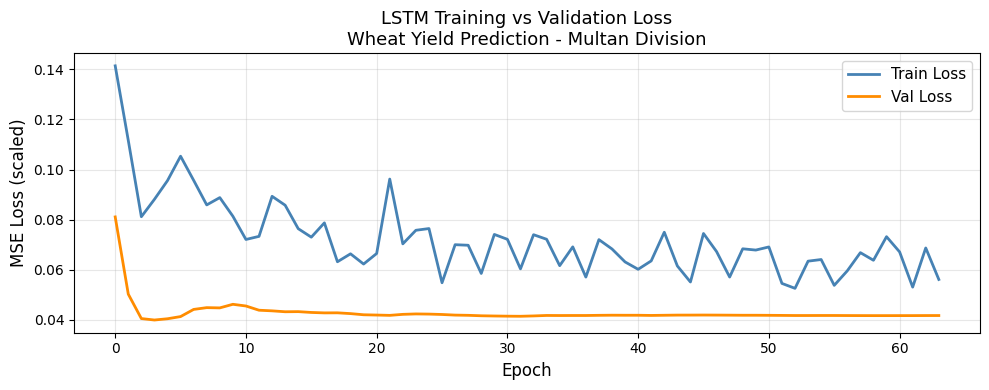

Loss curve saved to Drive.


In [ ]:
# ============================================================
# CELL 8: Confirm v2 as Final Model + Loss Curve
# ============================================================

model_lstm    = model_lstm2
history_final = history2

y_pred_train_final = y_pred_train_f2
y_pred_test_final  = y_pred_test_f2

r2_train   = r2_tr2
r2_test    = r2_te2
rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_pred_train_final))
mae_train  = mean_absolute_error(y_train_orig, y_pred_train_final)
rmse_test  = rmse_te2
mae_test   = mae_te2

results_lstm = pd.DataFrame({
    'Year':      yr_test_seq,
    'District':  dist_test_seq,
    'Actual':    y_test_orig.round(2),
    'Predicted': y_pred_test_final.round(2),
    'Error':     (y_test_orig - y_pred_test_final).round(2)
})

print('=== FINAL LSTM RESULTS (v2) ===')
print(f'Train R²   : {r2_train:.4f}')
print(f'Train RMSE : {rmse_train:.4f} maund/acre')
print(f'Train MAE  : {mae_train:.4f} maund/acre')
print(f'Test  R²   : {r2_test:.4f}')
print(f'Test  RMSE : {rmse_test:.4f} maund/acre')
print(f'Test  MAE  : {mae_test:.4f} maund/acre')
print()
print('Actual vs Predicted (Test Set 2021-2025):')
print(results_lstm.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(history_final.history['loss'],     label='Train Loss', linewidth=2, color='steelblue')
plt.plot(history_final.history['val_loss'], label='Val Loss',   linewidth=2, color='darkorange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss (scaled)', fontsize=12)
plt.title('LSTM Training vs Validation Loss\nWheat Yield Prediction - Multan Division', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'LSTM_Loss_Curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curve saved to Drive.')

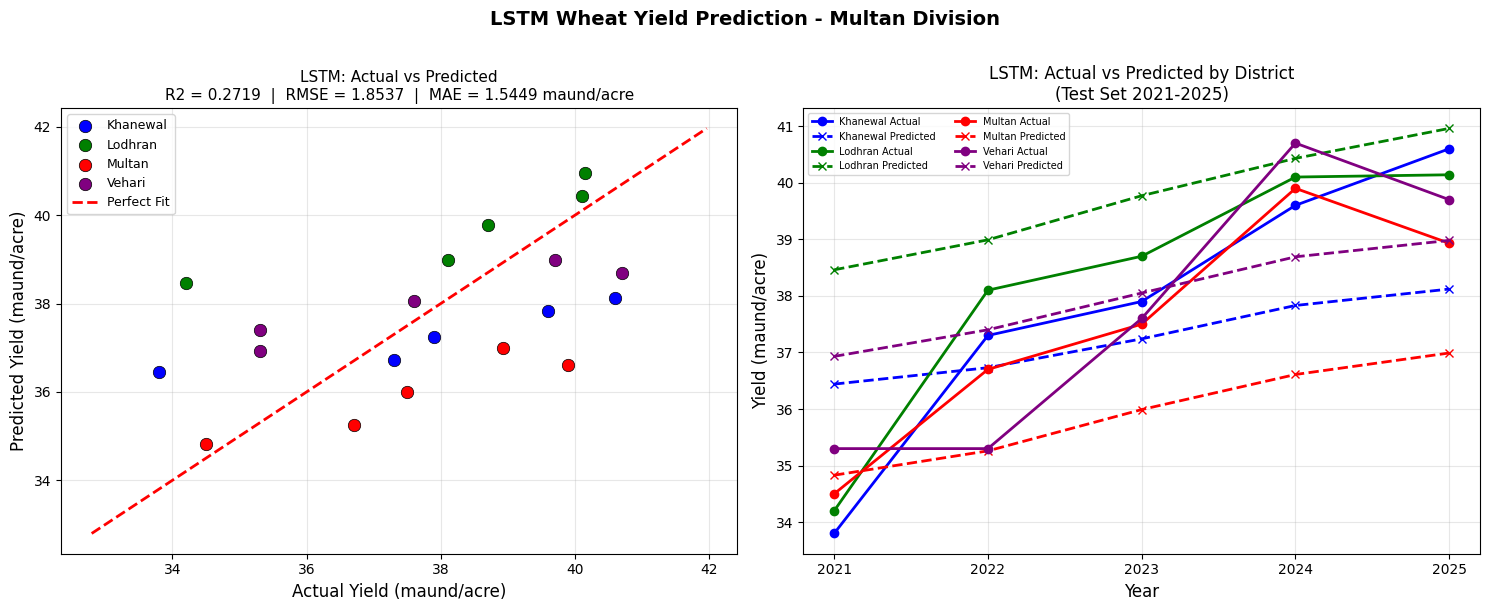

Plot saved to Drive: LSTM_Actual_vs_Predicted.png


In [ ]:
# ============================================================
# CELL 9: Actual vs Predicted Plots
# ============================================================

colors_dist = {
    'Khanewal': 'blue', 'Lodhran': 'green',
    'Multan':   'red',  'Vehari':  'purple'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for dist in districts:
    mask = results_lstm['District'] == dist
    ax1.scatter(results_lstm.loc[mask, 'Actual'], results_lstm.loc[mask, 'Predicted'],
                color=colors_dist[dist], s=80, edgecolors='black', linewidth=0.5, label=dist, zorder=3)

mn = min(results_lstm['Actual'].min(), results_lstm['Predicted'].min()) - 1
mx = max(results_lstm['Actual'].max(), results_lstm['Predicted'].max()) + 1
ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
ax1.set_xlabel('Actual Yield (maund/acre)', fontsize=12)
ax1.set_ylabel('Predicted Yield (maund/acre)', fontsize=12)
ax1.set_title(f'LSTM: Actual vs Predicted\nR2 = {r2_test:.4f}  |  RMSE = {rmse_test:.4f}  |  MAE = {mae_test:.4f} maund/acre', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for dist in districts:
    sub = results_lstm[results_lstm['District'] == dist].sort_values('Year')
    ax2.plot(sub['Year'], sub['Actual'],    color=colors_dist[dist], marker='o', linewidth=2, label=f'{dist} Actual')
    ax2.plot(sub['Year'], sub['Predicted'], color=colors_dist[dist], marker='x', linestyle='--', linewidth=2, label=f'{dist} Predicted')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Yield (maund/acre)', fontsize=12)
ax2.set_title('LSTM: Actual vs Predicted by District\n(Test Set 2021-2025)', fontsize=12)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([2021, 2022, 2023, 2024, 2025])

plt.suptitle('LSTM Wheat Yield Prediction - Multan Division', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'LSTM_Actual_vs_Predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Drive: LSTM_Actual_vs_Predicted.png')

=== RESIDUAL STATISTICS ===
Mean   : 0.0935
Std    : 1.8999
Min    : -4.2600
Max    : 3.2900

Within +-2 maund/acre: 14/20 = 70.0%
Within +-3 maund/acre: 18/20 = 90.0%


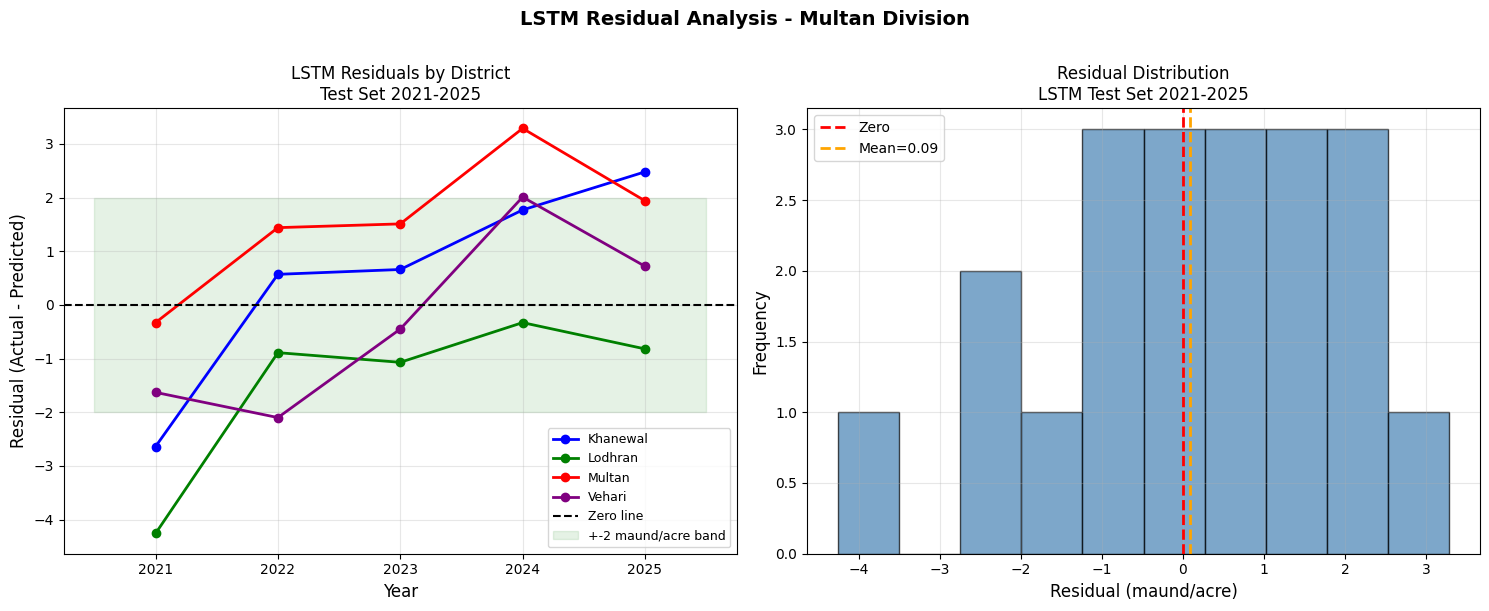

Plot saved to Drive: LSTM_Residuals.png


In [ ]:
# ============================================================
# CELL 10: Residual Analysis
# ============================================================

results_lstm['Residual'] = results_lstm['Actual'] - results_lstm['Predicted']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for dist in districts:
    sub = results_lstm[results_lstm['District'] == dist].sort_values('Year')
    ax1.plot(sub['Year'], sub['Residual'], color=colors_dist[dist], marker='o', linewidth=2, label=dist)

ax1.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero line')
ax1.fill_between([2020.5, 2025.5], -2, 2, alpha=0.1, color='green', label='+-2 maund/acre band')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax1.set_title('LSTM Residuals by District\nTest Set 2021-2025', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks([2021, 2022, 2023, 2024, 2025])

ax2 = axes[1]
ax2.hist(results_lstm['Residual'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax2.axvline(results_lstm['Residual'].mean(), color='orange', linestyle='--', linewidth=2,
            label=f'Mean={results_lstm["Residual"].mean():.2f}')
ax2.set_xlabel('Residual (maund/acre)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residual Distribution\nLSTM Test Set 2021-2025', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

print('=== RESIDUAL STATISTICS ===')
print(f'Mean   : {results_lstm["Residual"].mean():.4f}')
print(f'Std    : {results_lstm["Residual"].std():.4f}')
print(f'Min    : {results_lstm["Residual"].min():.4f}')
print(f'Max    : {results_lstm["Residual"].max():.4f}')
print()
within_2 = (results_lstm['Residual'].abs() <= 2).sum()
within_3 = (results_lstm['Residual'].abs() <= 3).sum()
total    = len(results_lstm)
print(f'Within +-2 maund/acre: {within_2}/{total} = {within_2/total*100:.1f}%')
print(f'Within +-3 maund/acre: {within_3}/{total} = {within_3/total*100:.1f}%')

plt.suptitle('LSTM Residual Analysis - Multan Division', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'LSTM_Residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Drive: LSTM_Residuals.png')

In [ ]:
# ============================================================
# CELL 11: Save LSTM Model + Predictions to Google Drive
# ============================================================
import pickle

model_lstm.save(DRIVE_PATH + 'lstm_wheat_model.keras')
print('LSTM model saved: lstm_wheat_model.keras')

with open(DRIVE_PATH + 'lstm_x_scaler.pkl', 'wb') as f:
    pickle.dump(x_scaler, f)
with open(DRIVE_PATH + 'lstm_y_scaler.pkl', 'wb') as f:
    pickle.dump(y_scaler, f)
print('Scalers saved.')

with open(DRIVE_PATH + 'lstm_trend_models.pkl', 'wb') as f:
    pickle.dump(trend_models, f)
print('Trend models saved.')

np.save(DRIVE_PATH + 'lstm_y_pred_test.npy',  y_pred_test_final)
np.save(DRIVE_PATH + 'lstm_y_pred_train.npy', y_pred_train_final)
np.save(DRIVE_PATH + 'lstm_y_test.npy',       y_test_orig)
np.save(DRIVE_PATH + 'lstm_y_train.npy',      y_train_orig)
np.save(DRIVE_PATH + 'lstm_trend_test.npy',   trend_test_seq)
np.save(DRIVE_PATH + 'lstm_trend_train.npy',  trend_train_seq)
np.save(DRIVE_PATH + 'lstm_yr_test.npy',      yr_test_seq)
np.save(DRIVE_PATH + 'lstm_dist_test.npy',    dist_test_seq)
print('Predictions saved for hybrid ensemble.')

print()
print('=' * 55)
print('       LSTM STANDALONE - FINAL SUMMARY')
print('=' * 55)
print(f'  Method         : LSTM + Linear Trend Correction')
print(f'  Architecture   : 2-layer LSTM (16-8 units)')
print(f'  Train period   : 2002-2020 (64 sequences)')
print(f'  Test period    : 2021-2025 (20 sequences)')
print(f'  Sequence length: 3 years')
print(f'  Features used  : 9')
print()
print(f'  Train R2       : {r2_train:.4f}')
print(f'  Train RMSE     : {rmse_train:.4f} maund/acre')
print(f'  Train MAE      : {mae_train:.4f} maund/acre')
print()
print(f'  Test  R2       : {r2_test:.4f}')
print(f'  Test  RMSE     : {rmse_test:.4f} maund/acre')
print(f'  Test  MAE      : {mae_test:.4f} maund/acre')
print('=' * 55)
print()
print('All files saved to Google Drive: Colab Notebooks/')
print('Next step: TCN standalone notebook')

LSTM model saved: lstm_wheat_model.keras
Scalers saved.
Trend models saved.
Predictions saved for hybrid ensemble.

       LSTM STANDALONE - FINAL SUMMARY
  Method         : LSTM + Linear Trend Correction
  Architecture   : 2-layer LSTM (16-8 units)
  Train period   : 2002-2020 (64 sequences)
  Test period    : 2021-2025 (20 sequences)
  Sequence length: 3 years
  Features used  : 9

  Train R2       : 0.6172
  Train RMSE     : 1.9870 maund/acre
  Train MAE      : 1.5214 maund/acre

  Test  R2       : 0.2719
  Test  RMSE     : 1.8537 maund/acre
  Test  MAE      : 1.5449 maund/acre

All files saved to Google Drive: Colab Notebooks/
Next step: TCN standalone notebook


Computing SHAP values - may take 1-2 minutes...


  0%|          | 0/20 [00:00<?, ?it/s]

SHAP values computed


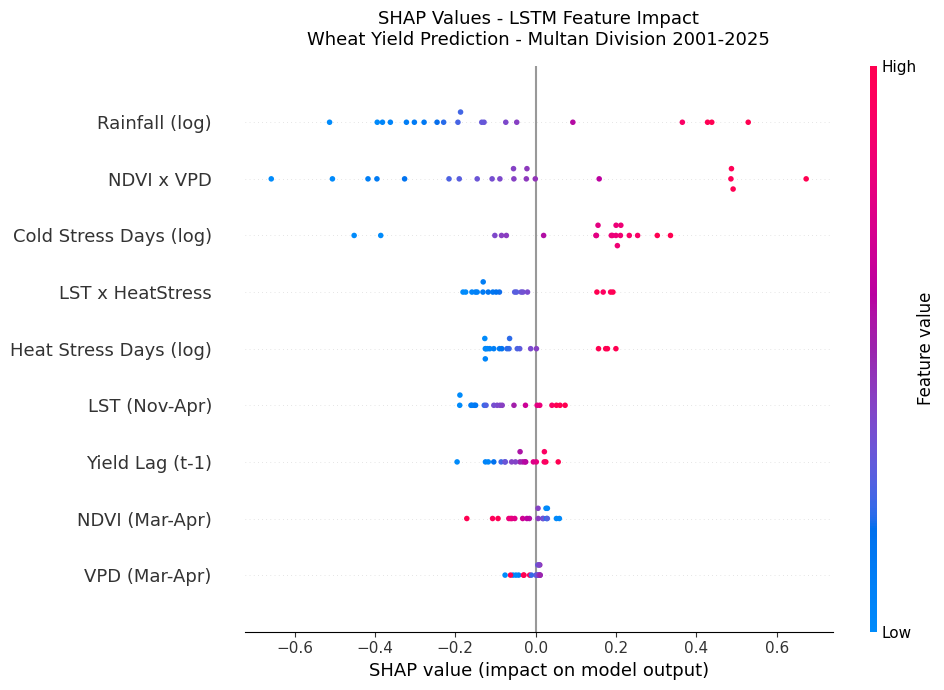

SHAP summary plot saved to Drive.


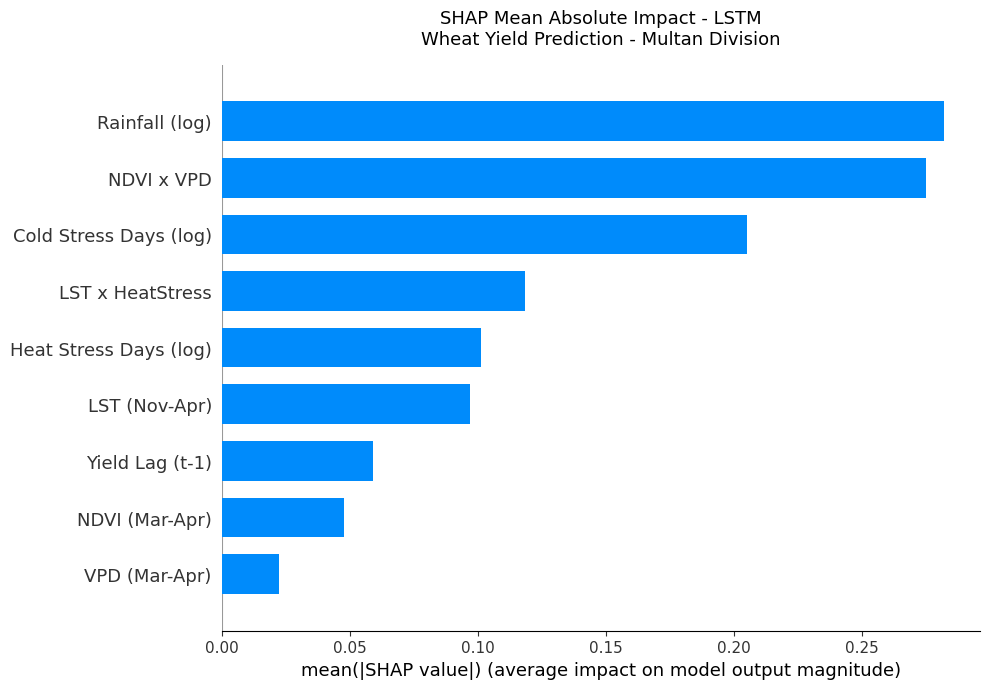

SHAP bar plot saved to Drive.

=== SHAP MEAN ABSOLUTE VALUES - LSTM ===
               Feature  Mean_SHAP
        Rainfall (log)   0.282152
            NDVI x VPD   0.275120
Cold Stress Days (log)   0.205152
      LST x HeatStress   0.118586
Heat Stress Days (log)   0.101253
         LST (Nov-Apr)   0.097103
       Yield Lag (t-1)   0.059243
        NDVI (Mar-Apr)   0.047631
         VPD (Mar-Apr)   0.022526


In [ ]:
# ============================================================
# CELL 12: SHAP Analysis for LSTM
# Uses KernelExplainer — works on any model
# Consistent wrapper with original LSTM methodology
# ============================================================
!pip install shap --quiet

import shap

# Reset seed for reproducibility
np.random.seed(SEED)

# Feature names for display
feature_names_clean = [
    'NDVI (Mar-Apr)',
    'LST (Nov-Apr)',
    'Rainfall (log)',
    'VPD (Mar-Apr)',
    'Heat Stress Days (log)',
    'Cold Stress Days (log)',
    'Yield Lag (t-1)',
    'NDVI x VPD',
    'LST x HeatStress'
]

# Reshape for SHAP — take last timestep as representative
X_train_2d = X_train_s[:, -1, :]  # shape (64, 9)
X_test_2d  = X_test_s[:, -1, :]   # shape (20, 9)

# Sample 30 background points from training
background = X_train_2d[
    np.random.choice(X_train_2d.shape[0], 30, replace=False)
]

# Wrapper function for LSTM prediction
def lstm_predict(x):
    x_3d = np.repeat(x[:, np.newaxis, :], n_timesteps, axis=1)
    pred_s  = model_lstm.predict(x_3d, verbose=0).flatten()
    pred_dt = y_scaler.inverse_transform(
        pred_s.reshape(-1, 1)
    ).flatten()
    return pred_dt

# Create explainer
explainer = shap.KernelExplainer(lstm_predict, background)

print('Computing SHAP values - may take 1-2 minutes...')
shap_values = explainer.shap_values(X_test_2d, nsamples=100)
print('SHAP values computed')

# -------------------------------------------------------
# Plot 1: SHAP Beeswarm
# -------------------------------------------------------
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_2d,
    feature_names=feature_names_clean,
    show=False,
    plot_size=(10, 7)
)
plt.title(
    'SHAP Values - LSTM Feature Impact\n'
    'Wheat Yield Prediction - Multan Division 2001-2025',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'LSTM_SHAP_Summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('SHAP summary plot saved to Drive.')

# -------------------------------------------------------
# Plot 2: SHAP Bar Plot
# -------------------------------------------------------
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_2d,
    feature_names=feature_names_clean,
    plot_type='bar',
    show=False,
    plot_size=(10, 7)
)
plt.title(
    'SHAP Mean Absolute Impact - LSTM\n'
    'Wheat Yield Prediction - Multan Division',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'LSTM_SHAP_Bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('SHAP bar plot saved to Drive.')

# -------------------------------------------------------
# SHAP ranking table
# -------------------------------------------------------
shap_df_lstm = pd.DataFrame({
    'Feature':   feature_names_clean,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print()
print('=== SHAP MEAN ABSOLUTE VALUES - LSTM ===')
print(shap_df_lstm.to_string(index=False))